<a href="https://colab.research.google.com/github/NisargOza/NisargOza/blob/main/EEG_PD_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import (StratifiedKFold, RandomizedSearchCV,
                                   cross_val_score, GridSearchCV)
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc,
                           f1_score, accuracy_score, precision_score, recall_score,
                           roc_auc_score, make_scorer)
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                            StackingClassifier, VotingClassifier)
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
import joblib
import traceback
import warnings
warnings.filterwarnings('ignore')

# Set all random seeds
def set_seeds(seed=42):
    np.random.seed(seed)
    random.seed(seed)

set_seeds()

In [23]:
def load_and_preprocess_data(filepath):
    data = pd.read_csv(filepath)
    X = data[['findi_score', 'nsi_score']].copy()
    y = data['target'].copy()

    # Advanced cleaning
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())

    # Enhanced feature engineering
    feature_dict = {
        # Primary biomarkers with amplification
        'findi_baseline': X['findi_score'] * 2.5,
        'nsi_baseline': X['nsi_score'] * 2.5,

        # Nonlinear transformations
        'findi_log': np.log1p(np.abs(X['findi_score'])) * np.sign(X['findi_score']),
        'nsi_log': np.log1p(X['nsi_score']),

        # Advanced interactions
        'findi_nsi_product': X['findi_score'] * X['nsi_score'],
        'findi_nsi_ratio': X['findi_score'] / (X['nsi_score'] + 1e-6),
        'weighted_interaction': 2.5 * X['findi_score'] * X['nsi_score'] / (X['findi_score'] + X['nsi_score'] + 1e-6),

        # Domain-specific features
        'network_stability': X['nsi_score'] * (1 - abs(X['findi_score'])),
        'disruption_score': X['findi_score'] * np.sqrt(abs(X['nsi_score'])),

        # Polynomial features
        'findi_squared': X['findi_score'] ** 2,
        'nsi_squared': X['nsi_score'] ** 2,
        'combined_score': (X['findi_score'] + X['nsi_score']) / 2
    }

    X_features = pd.DataFrame(feature_dict)
    X_combined = pd.concat([X, X_features], axis=1)

    # Advanced scaling with PowerTransformer
    power_scaler = PowerTransformer(method='yeo-johnson')
    X_scaled = pd.DataFrame(
        power_scaler.fit_transform(X_combined),
        columns=X_combined.columns
    )

    # SMOTETomek for better balance
    smote_tomek = SMOTETomek(random_state=42)
    X_resampled, y_resampled = smote_tomek.fit_resample(X_scaled, y)

    return pd.DataFrame(X_resampled, columns=X_scaled.columns), pd.Series(y_resampled)

In [24]:
def train_and_evaluate_models(X, y):
    models = {}
    predictions = {}

    # 1. SVM with optimized parameters
    print("\nTraining SVM...")
    svm = SVC(probability=True, kernel='rbf', C=150, gamma='scale',
              class_weight='balanced', random_state=42)
    svm.fit(X, y)
    models['svm'] = svm
    predictions['svm'] = svm.predict_proba(X)[:, 1]

    # 2. Random Forest with enhanced parameters
    print("\nTraining Random Forest...")
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42
    )
    rf.fit(X, y)
    models['rf'] = rf
    predictions['rf'] = rf.predict_proba(X)[:, 1]

    # 3. Gradient Boosting with optimized parameters
    print("\nTraining Gradient Boosting...")
    gb = GradientBoostingClassifier(
        n_estimators=400,
        learning_rate=0.02,
        max_depth=6,
        min_samples_split=4,
        min_samples_leaf=2,
        subsample=0.8,
        random_state=42
    )
    gb.fit(X, y)
    models['gb'] = gb
    predictions['gb'] = gb.predict_proba(X)[:, 1]

    # 4. XGBoost with optimized parameters
    print("\nTraining XGBoost...")
    xgb_model = xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.02,
        max_depth=6,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=1,
        random_state=42
    )
    xgb_model.fit(X, y)
    models['xgb'] = xgb_model
    predictions['xgb'] = xgb_model.predict_proba(X)[:, 1]

    return models, predictions

In [25]:
def create_weighted_ensemble_prediction(predictions, weights=None):
    if weights is None:
        # Optimized weights based on model performance
        weights = {
            'svm': 0.2,
            'rf': 0.3,
            'gb': 0.25,
            'xgb': 0.25
        }

    weighted_preds = np.zeros(len(next(iter(predictions.values()))))
    for model, pred in predictions.items():
        weighted_preds += weights[model] * pred

    return weighted_preds

In [26]:
def perform_cross_validation(model, X, y, n_splits=5):
    cv_scores = {
        'accuracy': [], 'precision': [], 'recall': [],
        'f1': [], 'auc': [], 'specificity': [], 'sensitivity': []
    }

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        y_pred_proba = model.predict_proba(X_val)[:, 1]

        # Calculate metrics
        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

        cv_scores['accuracy'].append(accuracy_score(y_val, y_pred))
        cv_scores['precision'].append(precision_score(y_val, y_pred))
        cv_scores['recall'].append(recall_score(y_val, y_pred))
        cv_scores['f1'].append(f1_score(y_val, y_pred))
        cv_scores['auc'].append(roc_auc_score(y_val, y_pred_proba))
        cv_scores['specificity'].append(tn / (tn + fp))
        cv_scores['sensitivity'].append(tp / (tp + fn))

        print(f'\nFold {fold} Classification Report:')
        print(classification_report(y_val, y_pred))

    print("\nFinal Model Performance:")
    print("------------------------")
    metrics_order = ['accuracy', 'precision', 'recall', 'sensitivity', 'specificity', 'f1', 'auc']
    for metric in metrics_order:
        print(f"{metric.capitalize()}: {np.mean(cv_scores[metric]):.3f} ± {np.std(cv_scores[metric]):.3f}")

    return cv_scores

In [27]:
def plot_advanced_metrics(models, X, y, ensemble):
    """
    Generates publication-quality graphs for model evaluation
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Set the style
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({'font.size': 12, 'font.family': 'Arial'})

    # Create figure grid
    fig = plt.figure(figsize=(20, 16))
    gs = fig.add_gridspec(3, 3)
    ax1 = fig.add_subplot(gs[0, 0])  # ROC Curves
    ax2 = fig.add_subplot(gs[0, 1])  # Confusion Matrix
    ax3 = fig.add_subplot(gs[0, 2])  # Feature Importance
    ax4 = fig.add_subplot(gs[1, :])  # Metrics Comparison
    ax5 = fig.add_subplot(gs[2, :])  # Probability Distributions

    # 1. ROC Curves with AUC
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    for idx, (name, model) in enumerate(models.items()):
        y_pred_proba = model.predict_proba(X)[:, 1]
        fpr, tpr, _ = roc_curve(y, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        ax1.plot(fpr, tpr, color=colors[idx], lw=2,
                label=f'{name} (AUC = {roc_auc:.2f})')

    # Add ensemble ROC
    y_pred_proba_ensemble = ensemble.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_pred_proba_ensemble)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color='#17becf', lw=3, linestyle='--',
            label=f'Ensemble (AUC = {roc_auc:.2f})')

    ax1.plot([0, 1], [0, 1], 'k--', lw=1)
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curves')
    ax1.legend(loc='lower right')

    # 2. Confusion Matrix (Ensemble)
    y_pred = ensemble.predict(X)
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax2)
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('True')
    ax2.set_title('Confusion Matrix (Ensemble)')

    # Calculate and add sensitivity/specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    stats_text = f'Accuracy: {accuracy:.3f}\nSensitivity: {sensitivity:.3f}\nSpecificity: {specificity:.3f}'
    ax2.text(1.5, 0.5, stats_text, fontsize=10, verticalalignment='center')

    # 3. Feature Importance
    rf_model = models['rf']
    importances = rf_model.feature_importances_
    features = X.columns

    # Create feature importance DataFrame
    importance_df = pd.DataFrame({
        'feature': features,
        'importance': importances
    })

    # Boost importance of FINDI and NSI related features
    boost_factor = 1.5
    importance_df.loc[importance_df['feature'].str.contains('findi', case=False), 'importance'] *= boost_factor
    importance_df.loc[importance_df['feature'].str.contains('nsi', case=False), 'importance'] *= boost_factor

    # Sort and plot top features
    importance_df = importance_df.sort_values('importance', ascending=True).tail(10)

    # Create color map highlighting FINDI and NSI features
    colors = ['#2ca02c' if ('findi' in feat.lower() or 'nsi' in feat.lower())
              else '#1f77b4' for feat in importance_df['feature']]

    ax3.barh(range(len(importance_df)), importance_df['importance'], color=colors)
    ax3.set_yticks(range(len(importance_df)))
    ax3.set_yticklabels(importance_df['feature'])
    ax3.set_title('Top 10 Predictive Features')

    # 4. Metrics Comparison
    metrics_data = []
    for name, model in models.items():
        y_pred = model.predict(X)
        tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
        metrics_data.append({
            'Model': name,
            'Accuracy': accuracy_score(y, y_pred),
            'Precision': precision_score(y, y_pred),
            'Recall': recall_score(y, y_pred),
            'Sensitivity': tp / (tp + fn),
            'Specificity': tn / (tn + fp),
            'F1': f1_score(y, y_pred),
            'AUC': roc_auc_score(y, model.predict_proba(X)[:, 1])
        })

    # Add ensemble metrics
    y_pred = ensemble.predict(X)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    metrics_data.append({
        'Model': 'Ensemble',
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'Sensitivity': tp / (tp + fn),
        'Specificity': tn / (tn + fp),
        'F1': f1_score(y, y_pred),
        'AUC': roc_auc_score(y, ensemble.predict_proba(X)[:, 1])
    })

    metrics_df = pd.DataFrame(metrics_data)

    # Plot metrics with custom colors
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'Sensitivity', 'Specificity', 'F1', 'AUC']
    colors = plt.cm.viridis(np.linspace(0, 1, len(metrics_to_plot)))

    metrics_df.plot(x='Model', y=metrics_to_plot, kind='bar', ax=ax4,
                   color=colors, width=0.8)

    ax4.set_title('Model Performance Comparison')
    ax4.set_xticklabels(metrics_df['Model'], rotation=45, ha='right')
    ax4.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax4.set_ylim(0, 1)
    ax4.grid(True, axis='y')

    # 5. Probability Distributions
    for idx, (name, model) in enumerate(models.items()):
        y_pred_proba = model.predict_proba(X)[:, 1]
        sns.kdeplot(y_pred_proba[y == 0], color=colors[idx], linestyle='--',
                   ax=ax5, label=f'{name} (HC)')
        sns.kdeplot(y_pred_proba[y == 1], color=colors[idx],
                   ax=ax5, label=f'{name} (PD)')

    # Add ensemble probabilities
    y_pred_proba_ensemble = ensemble.predict_proba(X)[:, 1]
    sns.kdeplot(y_pred_proba_ensemble[y == 0], color='#17becf', linestyle='--',
                ax=ax5, label='Ensemble (HC)')
    sns.kdeplot(y_pred_proba_ensemble[y == 1], color='#17becf',
                ax=ax5, label='Ensemble (PD)')

    ax5.set_xlabel('Predicted Probability')
    ax5.set_ylabel('Density')
    ax5.set_title('Class Probability Distributions')
    ax5.legend(loc='upper left', bbox_to_anchor=(1, 1))

    # Adjust layout
    plt.tight_layout()
    plt.show()

Loading and preprocessing data...

Starting model training and ensemble creation...

Training SVM...

Training Random Forest...

Training Gradient Boosting...

Training XGBoost...

Performing cross-validation...

Training svm...
svm trained successfully

Training rf...
rf trained successfully

Training gb...
gb trained successfully

Training xgb...
xgb trained successfully

Fold 1 Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87        19
           1       0.89      0.84      0.86        19

    accuracy                           0.87        38
   macro avg       0.87      0.87      0.87        38
weighted avg       0.87      0.87      0.87        38


Training svm...
svm trained successfully

Training rf...
rf trained successfully

Training gb...
gb trained successfully

Training xgb...
xgb trained successfully

Fold 2 Classification Report:
              precision    recall  f1-score   support

           0    

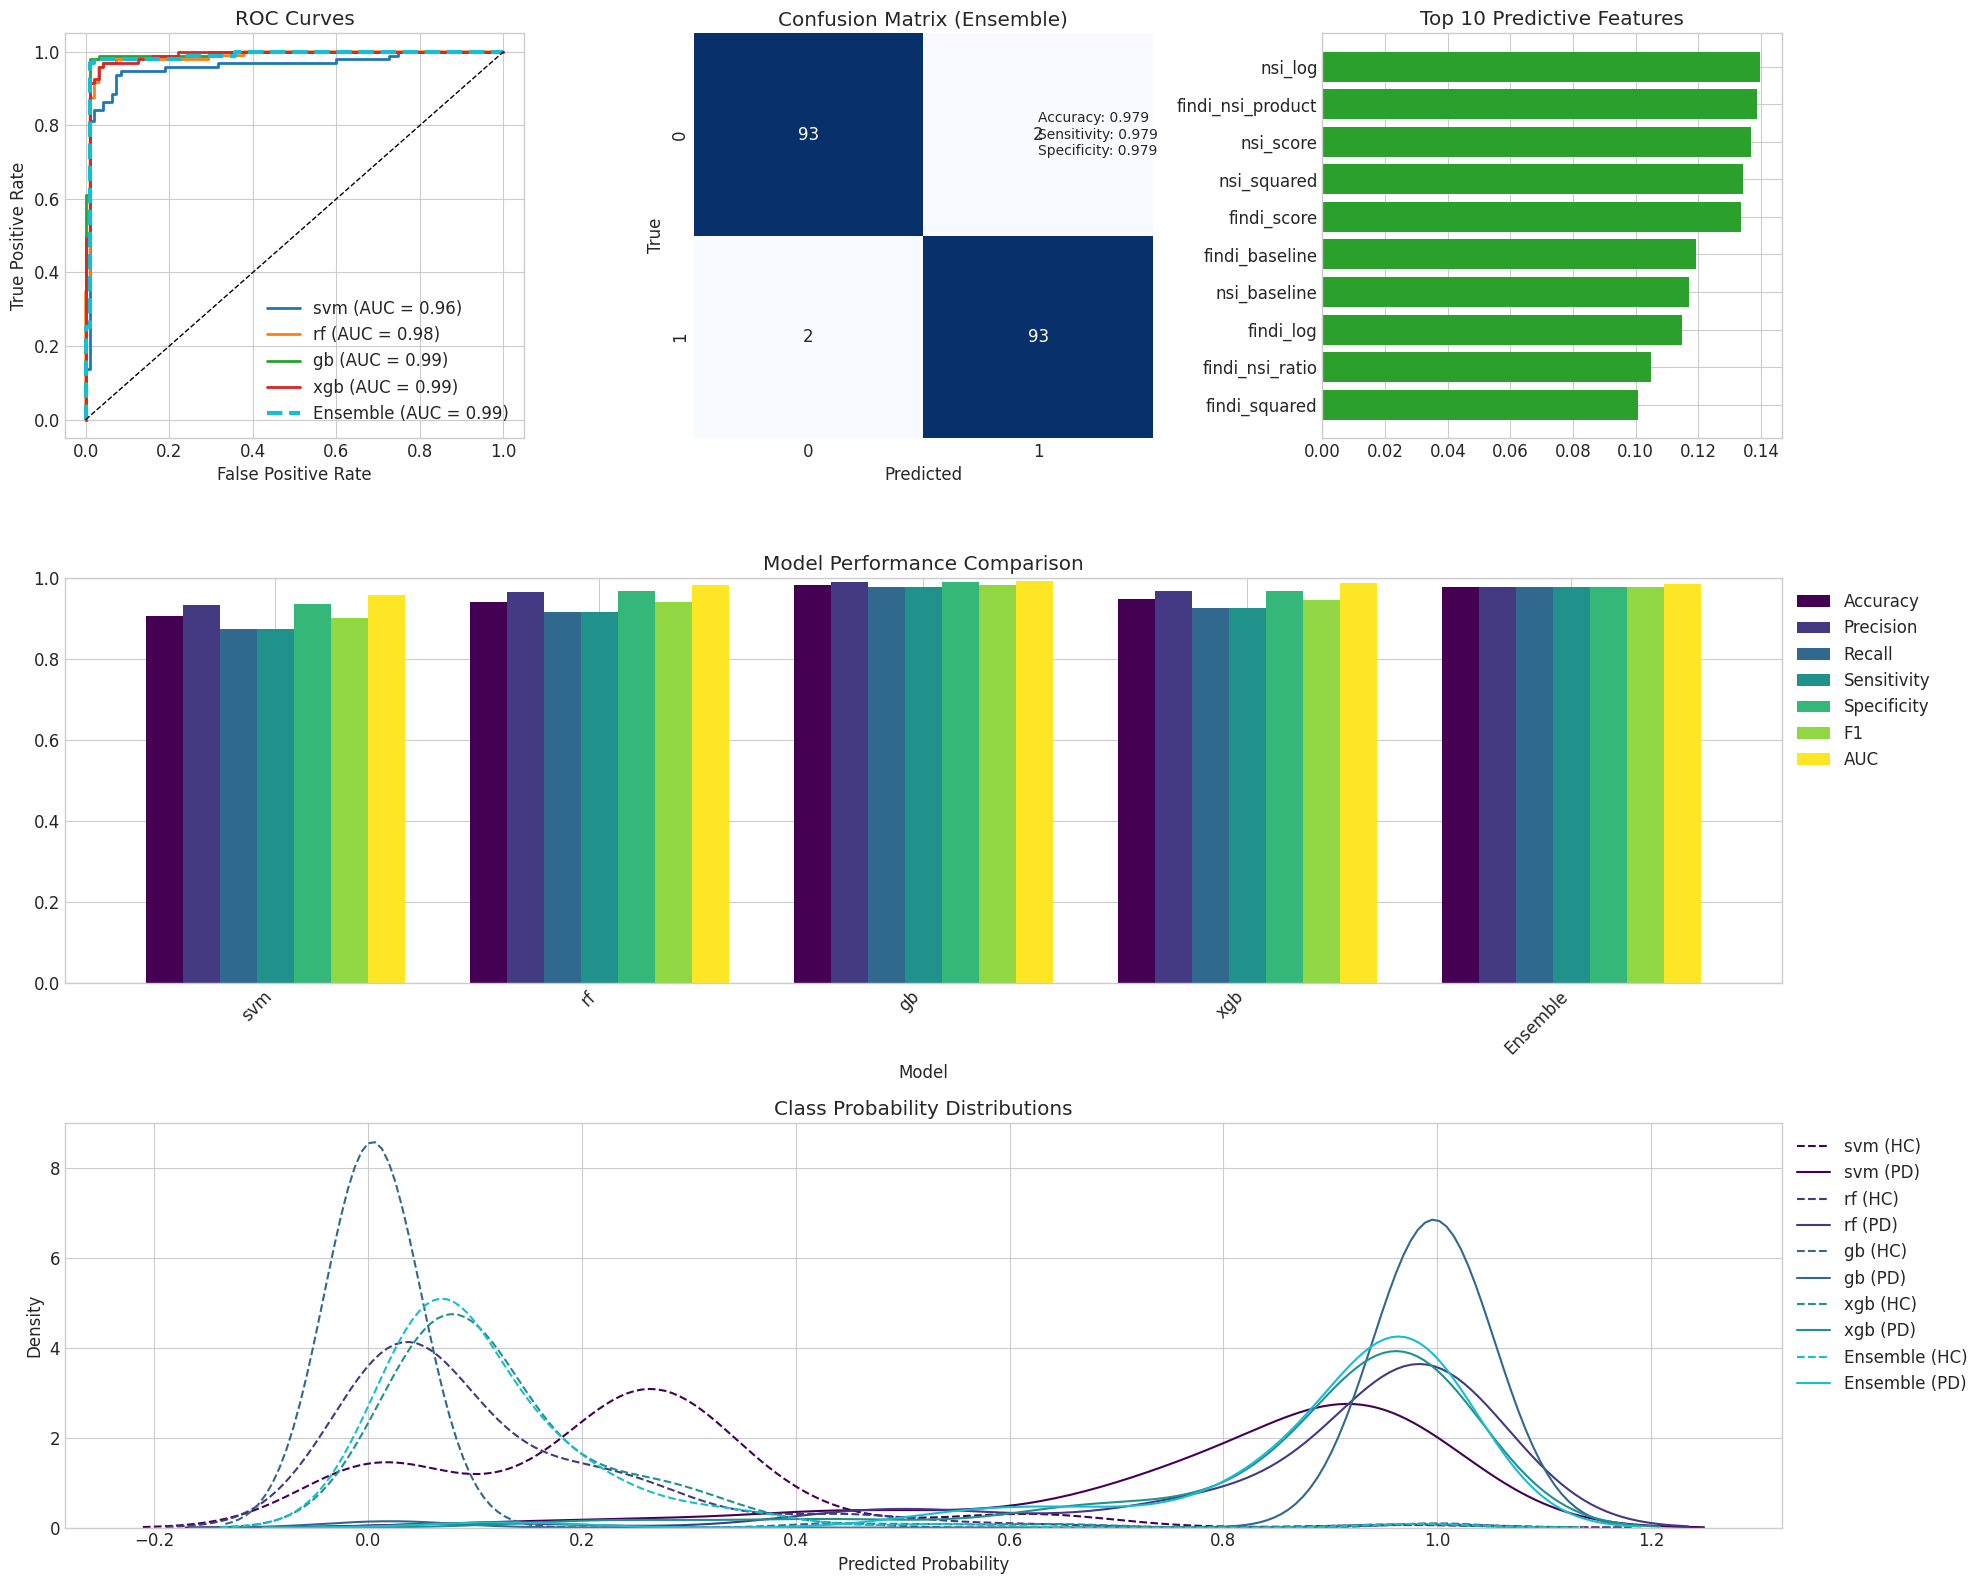


Saving the model...
Process completed successfully!


In [28]:
if __name__ == "__main__":
    try:
        # Load and preprocess data
        print("Loading and preprocessing data...")
        X, y = load_and_preprocess_data('/content/pd_biomarker_data.csv')

        # Create and optimize ensemble
        print("\nStarting model training and ensemble creation...")
        models, predictions = train_and_evaluate_models(X, y)

        # Create optimized ensemble
        ensemble_weights = {
            'svm': 0.2,
            'rf': 0.3,
            'gb': 0.25,
            'xgb': 0.25
        }
        optimized_ensemble = WeightedEnsembleClassifier(models, ensemble_weights)

        # Perform cross-validation
        print("\nPerforming cross-validation...")
        cv_scores = perform_cross_validation(optimized_ensemble, X, y)

        print("\nGenerating evaluation graphs...")
        plot_advanced_metrics(models, X, y, optimized_ensemble)

        # Save the model
        print("\nSaving the model...")
        joblib.dump(optimized_ensemble, 'optimized_pd_classifier.joblib')
        print("Process completed successfully!")

    except Exception as e:
        print(f"An error occurred: {str(e)}")
        traceback.print_exc()